# ALMA SODA Cutout Examples

This notebook imports `get_cutout` from the local `get_cutout.py` script and shows three common examples:

- a continuum cutout shown as an image
- HNCO moment-map cutouts shown as images
- an HNCO cube cutout reduced to a mean spectrum

Run this notebook from the same directory as `get_cutout.py`.

In [1]:
import sys
from pathlib import Path

HERE = Path.cwd()
if not (HERE / "get_cutout.py").exists():
    HERE = Path("aces/cutout_scripts")
sys.path.insert(0, str(HERE.resolve()))

import matplotlib.pyplot as plt
import numpy as np
from astropy import constants as const
from astropy import units as u
from astropy.io import fits

from get_cutout import get_cutout

In [2]:
GLON = 0.5121809495
GLAT = -0.0014974925
RADIUS_ARCSEC = 50
VMIN = -5 
VMAX = 65

OUTDIR = HERE / "example_outputs"
OUTDIR.mkdir(exist_ok=True)

CONTINUUM_ID = "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m.cont.93.7GHz_bw4.7GHz.pbcor.fits"
HNCO_MOM0_ID = "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HNCO.integrated_intensity.fits"
HNCO_PEAK_ID = "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HNCO.peak_intensity.fits"
HNCO_CUBE_ID = "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HNCO.cube.pbcor.fits"

In [3]:
import warnings

KNOWN_ACES_FILES = HERE / "known_aces_files.dat"


def known_aces_dataset_ids(path=KNOWN_ACES_FILES):
    return {
        line.strip()
        for line in path.read_text(encoding="utf-8-sig").splitlines()
        if line.strip()
    }


def download_if_needed(dataset_id, outfile, vmin=None, vmax=None):
    if dataset_id not in known_aces_dataset_ids():
        warnings.warn(
            f"Dataset ID is not listed in {KNOWN_ACES_FILES}; skipping download: {dataset_id}",
            stacklevel=2,
        )
        return None

    outfile = Path(outfile)
    # if outfile.exists():
    #     print(f"Using existing {outfile}")
    #     return outfile

    get_cutout(
        dataset_id,
        GLON,
        GLAT,
        RADIUS_ARCSEC,
        vmin=vmin,
        vmax=vmax,
        outfile=str(outfile),
    )
    return outfile


def image_plane(path):
    data = np.squeeze(fits.getdata(path))
    if data.ndim == 2:
        return data
    if data.ndim == 3:
        return np.nanmean(data, axis=0)
    raise ValueError(f"Expected a 2D image or 3D cube-like array, got shape {data.shape}")


def show_image(path, title, ax=None, cmap="inferno"):
    image = image_plane(path)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))

    finite = np.isfinite(image)
    vmin, vmax = np.nanpercentile(image[finite], [1, 99]) if finite.any() else (None, None)
    im = ax.imshow(image, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Pixel")
    ax.set_ylabel("Pixel")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return ax


def mean_spectrum(path):
    data = np.squeeze(fits.getdata(path))
    header = fits.getheader(path)
    if data.ndim != 3:
        raise ValueError(f"Expected a 3D cube after squeezing, got shape {data.shape}")

    spectrum = np.nanmean(data, axis=(1, 2))
    channels = np.arange(spectrum.size) + 1

    unit = u.Unit(header.get("CUNIT3", "Hz").strip() or "Hz")
    frequency = (header["CRVAL3"] + (channels - header["CRPIX3"]) * header["CDELT3"]) * unit
    rest_frequency = header.get("RESTFRQ", header.get("RESTFREQ")) * u.Hz
    velocity = ((1 - frequency.to(u.Hz) / rest_frequency) * const.c).to(u.km / u.s)
    return velocity.value, spectrum

## Continuum Image Cutout

https://almascience.eso.org/soda/sync?REQUEST=queryData&ID=group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m.cont.93.7GHz_bw4.7GHz.pbcor.fits&POS=CIRCLE+266.71009829+-28.49944794+0.01388889
200
application/fits
Wrote /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/ACES-CMZ/reduction_ACES/aces/cutout_scripts/example_outputs/continuum_20arcsec_narrowlines.fits


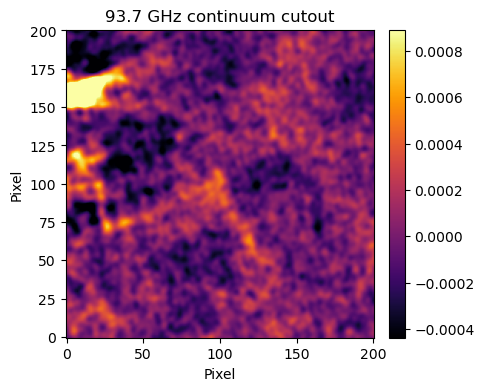

In [4]:
continuum_path = download_if_needed(
    CONTINUUM_ID,
    OUTDIR / "continuum_20arcsec_narrowlines.fits",
)

show_image(continuum_path, "93.7 GHz continuum cutout")
plt.show()

## HNCO Moment-Map Cutouts

https://almascience.eso.org/soda/sync?REQUEST=queryData&ID=group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HNCO.integrated_intensity.fits&POS=CIRCLE+266.71009829+-28.49944794+0.01388889
200
application/fits
Wrote /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/ACES-CMZ/reduction_ACES/aces/cutout_scripts/example_outputs/hnco_integrated_intensity_20arcsec_narrowlines.fits
https://almascience.eso.org/soda/sync?REQUEST=queryData&ID=group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HNCO.peak_intensity.fits&POS=CIRCLE+266.71009829+-28.49944794+0.01388889
200
application/fits
Wrote /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/ACES-CMZ/reduction_ACES/aces/cutout_scripts/example_outputs/hnco_peak_intensity_20arcsec_narrowlines.fits


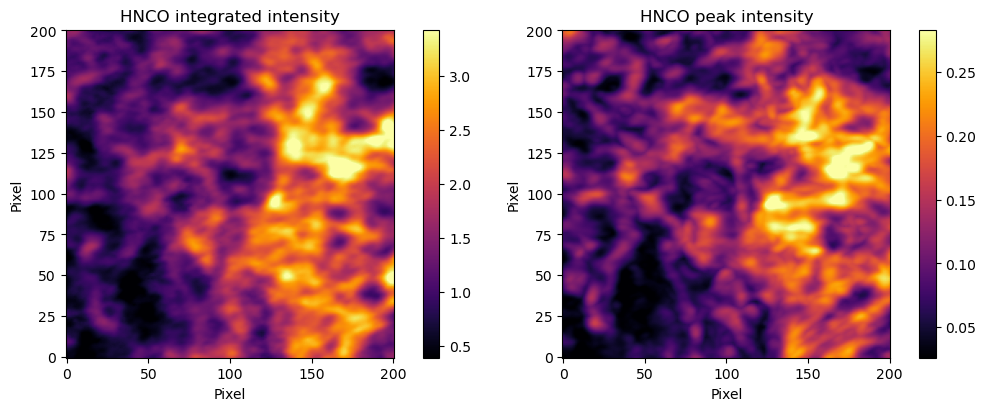

In [5]:
hnco_mom0_path = download_if_needed(
    HNCO_MOM0_ID,
    OUTDIR / "hnco_integrated_intensity_20arcsec_narrowlines.fits",
)
hnco_peak_path = download_if_needed(
    HNCO_PEAK_ID,
    OUTDIR / "hnco_peak_intensity_20arcsec_narrowlines.fits",
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
show_image(hnco_mom0_path, "HNCO integrated intensity", ax=axes[0])
show_image(hnco_peak_path, "HNCO peak intensity", ax=axes[1])
plt.show()

## HNCO Cube Cutout And Mean Spectrum

https://almascience.eso.org/soda/sync?REQUEST=queryData&ID=group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HNCO.cube.pbcor.fits&POS=CIRCLE+266.71009829+-28.49944794+0.00208333&BAND=3.40957232e-03+3.41036861e-03
200
application/fits
Wrote /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/ACES-CMZ/reduction_ACES/aces/cutout_scripts/example_outputs/HNCO_cube_20arcsec_m100_p100kms_narrowlines.fits


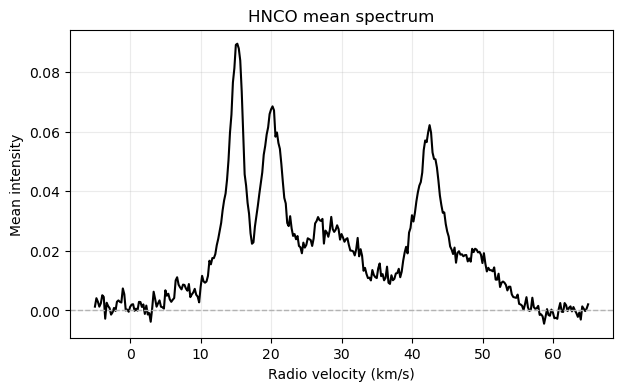

In [ ]:
GLON = 0.5119138841
GLAT = -0.0007131422
RADIUS_ARCSEC = 2.5

cube_path = download_if_needed(
    HNCO_CUBE_ID,
    OUTDIR / "HNCO_cube_20arcsec_m100_p100kms_narrowlines.fits",
    vmin=VMIN,
    vmax=VMAX,
)

velocity, spectrum = mean_spectrum(cube_path)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(velocity, spectrum, color="black", lw=1.5)
ax.axhline(0, color="0.7", lw=1, ls="--")
ax.set_xlabel("Radio velocity (km/s)")
ax.set_ylabel("Mean intensity")
ax.set_title("HNCO mean spectrum")
ax.grid(alpha=0.25)
plt.show()

https://almascience.eso.org/soda/sync?REQUEST=queryData&ID=group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.H13COplus.cube.pbcor.fits&POS=CIRCLE+266.70917765+-28.49926929+0.00069444&BAND=3.45559192e-03+3.45639896e-03
200
application/fits
Wrote /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/ACES-CMZ/reduction_ACES/aces/cutout_scripts/example_outputs/H13COplus_cube_2.5arcsec_-5_65kms_narrowlines.fits
https://almascience.eso.org/soda/sync?REQUEST=queryData&ID=group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HC3N.cube.pbcor.fits&POS=CIRCLE+266.70917765+-28.49926929+0.00069444&BAND=2.99558895e-03+2.99628855e-03
200
application/fits
Wrote /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/ACES-CMZ/reduction_ACES/aces/cutout_scripts/example_outputs/HC3N_cube_2.5arcsec_-5_65kms_narrowlines.fits
https://almascience.eso.org/soda/sync?REQUEST=queryData&ID=group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HCOplus.cube.pbcor.fits&POS=CIRCLE+266.

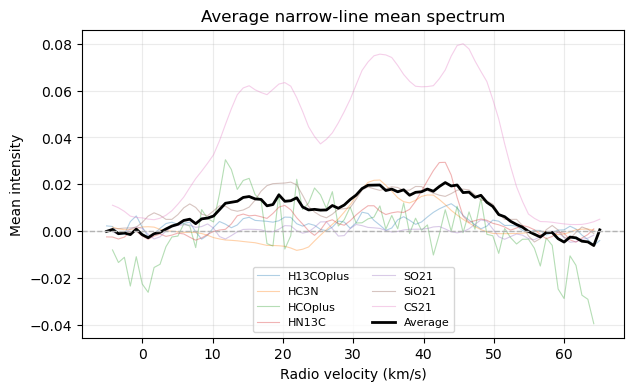

In [ ]:
GLON = 0.5119138841
GLAT = -0.0007131422
RADIUS_ARCSEC = 2.5

LINE_CUBE_IDS = {
    "HNCO": "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HNCO.cube.pbcor.fits",
    "H13COplus": "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.H13COplus.cube.pbcor.fits",
    "HC3N": "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HC3N.cube.pbcor.fits",
    "HCOplus": "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HCOplus.cube.pbcor.fits",
    "HN13C": "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HN13C.cube.pbcor.fits",
    "SO21": "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.SO21.cube.pbcor.fits",
    "SiO21": "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.SiO21.cube.pbcor.fits",
    "CS21": "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.CS21.cube.pbcor.fits",
}

line_spectra = {}
reference_velocity = None

for line_name, dataset_id in LINE_CUBE_IDS.items():
    cube_path = download_if_needed(
        dataset_id,
        OUTDIR / f"{line_name}_cube_{RADIUS_ARCSEC:g}arcsec_{VMIN:g}_{VMAX:g}kms_narrowlines.fits",
        vmin=VMIN,
        vmax=VMAX,
    )
    velocity, spectrum = mean_spectrum(cube_path)

    order = np.argsort(velocity)
    velocity = velocity[order]
    spectrum = spectrum[order]

    if reference_velocity is None:
        reference_velocity = velocity
        line_spectra[line_name] = spectrum
    else:
        line_spectra[line_name] = np.interp(
            reference_velocity,
            velocity,
            spectrum,
            left=np.nan,
            right=np.nan,
        )

average_velocity = reference_velocity
average_spectrum = np.nanmean(np.vstack(list(line_spectra.values())), axis=0)

fig, ax = plt.subplots(figsize=(7, 4))
for line_name, spectrum in line_spectra.items():
    ax.plot(average_velocity, spectrum, lw=0.8, alpha=0.35, label=line_name)
ax.plot(average_velocity, average_spectrum, color="black", lw=2.0, label="Average")
ax.axhline(0, color="0.7", lw=1, ls="--")
ax.set_xlabel("Radio velocity (km/s)")
ax.set_ylabel("Mean intensity")
ax.set_title("Average narrow-line mean spectrum")
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=8)
plt.show()

https://almascience.eso.org/soda/sync?REQUEST=queryData&ID=group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HNCO.cube.pbcor.fits&POS=CIRCLE+266.70917765+-28.49926929+0.00069444&BAND=3.40957232e-03+3.41036861e-03
200
application/fits
Wrote /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/ACES-CMZ/reduction_ACES/aces/cutout_scripts/example_outputs/HNCO_cube_2.5arcsec_-5_65kms_narrowlines.fits
https://almascience.eso.org/soda/sync?REQUEST=queryData&ID=group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.H13COplus.cube.pbcor.fits&POS=CIRCLE+266.70917765+-28.49926929+0.00069444&BAND=3.45559192e-03+3.45639896e-03
200
application/fits
Wrote /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/ACES-CMZ/reduction_ACES/aces/cutout_scripts/example_outputs/H13COplus_cube_2.5arcsec_-5_65kms_narrowlines.fits
https://almascience.eso.org/soda/sync?REQUEST=queryData&ID=group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HC3N.cube.pbcor.fits&POS=CIRCLE+266.709

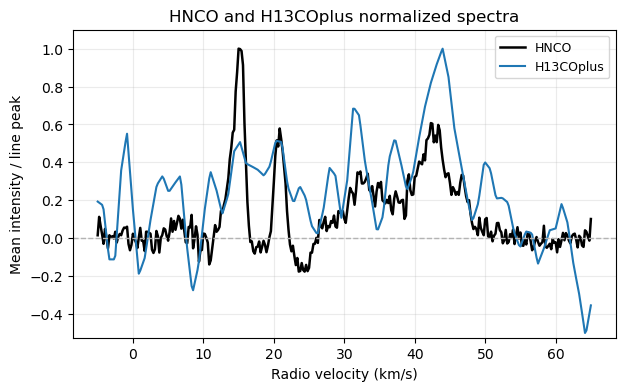

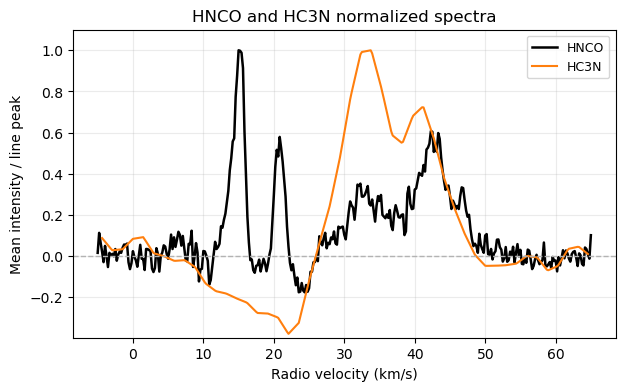

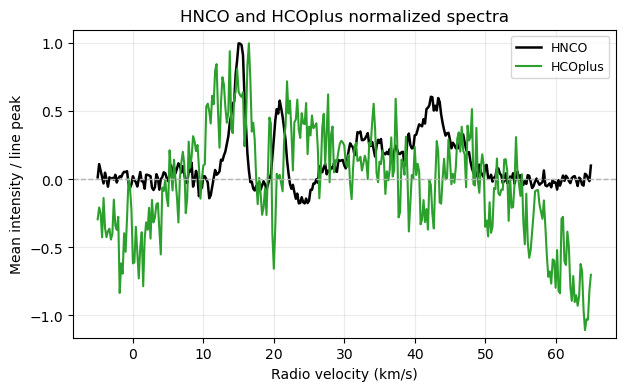

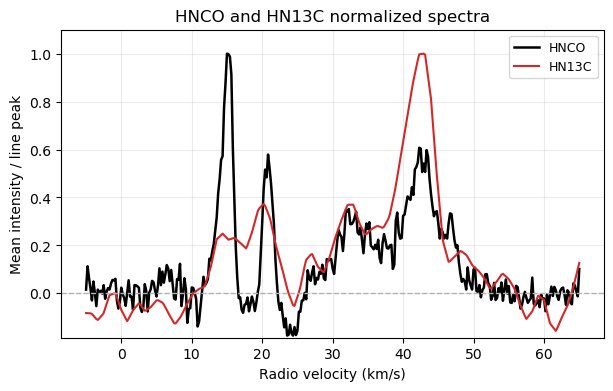

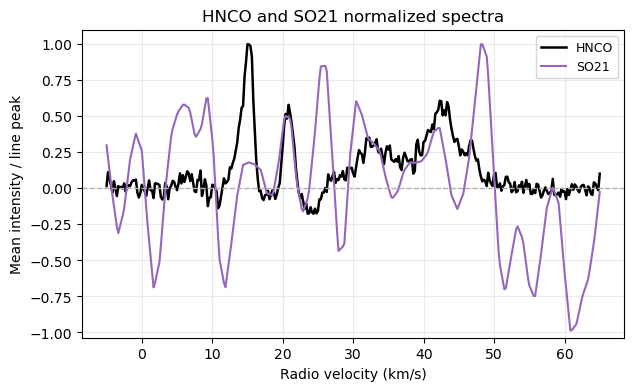

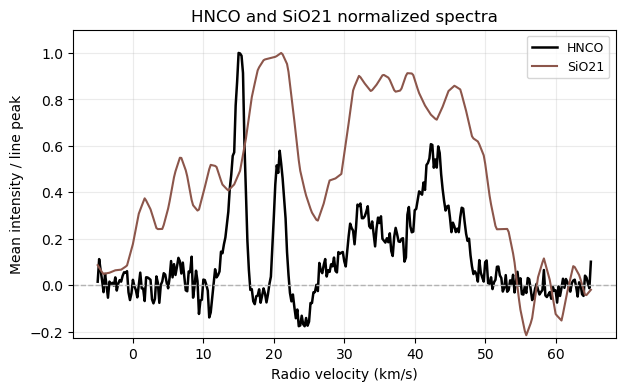

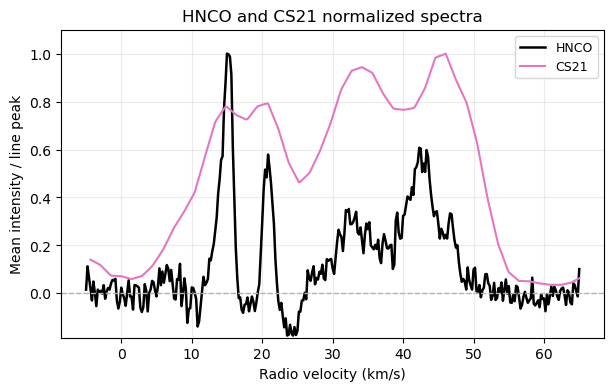

In [8]:
GLON = 0.5119138841
GLAT = -0.0007131422
RADIUS_ARCSEC = 2.5

LINE_CUBE_IDS = {
    "HNCO": "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HNCO.cube.pbcor.fits",
    "H13COplus": "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.H13COplus.cube.pbcor.fits",
    "HC3N": "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HC3N.cube.pbcor.fits",
    "HCOplus": "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HCOplus.cube.pbcor.fits",
    "HN13C": "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HN13C.cube.pbcor.fits",
    "SO21": "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.SO21.cube.pbcor.fits",
    "SiO21": "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.SiO21.cube.pbcor.fits",
    "CS21": "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.CS21.cube.pbcor.fits",
}

line_spectra = {}
reference_velocity = None

for line_name, dataset_id in LINE_CUBE_IDS.items():
    cube_path = download_if_needed(
        dataset_id,
        OUTDIR / f"{line_name}_cube_{RADIUS_ARCSEC:g}arcsec_{VMIN:g}_{VMAX:g}kms_narrowlines.fits",
        vmin=VMIN,
        vmax=VMAX,
    )
    velocity, spectrum = mean_spectrum(cube_path)

    order = np.argsort(velocity)
    velocity = velocity[order]
    spectrum = spectrum[order]

    if reference_velocity is None:
        reference_velocity = velocity
        line_spectra[line_name] = spectrum
    else:
        line_spectra[line_name] = np.interp(
            reference_velocity,
            velocity,
            spectrum,
            left=np.nan,
            right=np.nan,
        )

comparison_velocity = reference_velocity


def normalize_to_peak(spectrum):
    peak = np.nanmax(spectrum)
    if not np.isfinite(peak) or peak == 0:
        return spectrum * np.nan
    return spectrum / peak


hnco_spectrum = normalize_to_peak(line_spectra["HNCO"])
other_line_names = [line_name for line_name in LINE_CUBE_IDS if line_name != "HNCO"]
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for idx, line_name in enumerate(other_line_names):
    comparison_spectrum = normalize_to_peak(line_spectra[line_name])

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(comparison_velocity, hnco_spectrum, color="black", lw=1.8, label="HNCO")
    ax.plot(
        comparison_velocity,
        comparison_spectrum,
        color=colors[idx % len(colors)],
        lw=1.5,
        label=line_name,
    )
    ax.axhline(0, color="0.7", lw=1, ls="--")
    ax.set_xlabel("Radio velocity (km/s)")
    ax.set_ylabel("Mean intensity / line peak")
    ax.set_title(f"HNCO and {line_name} normalized spectra")
    ax.set_ylim(
        min(-0.1, np.nanmin([hnco_spectrum, comparison_spectrum]) * 1.05),
        1.1,
    )
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)
    plt.show()